In [ ]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns


In [134]:
df = pd.read_csv('csv_data/f1_race_data_v2.csv')
print(df.head())

                      Date  Season  Round CircuitLocation  LapNumber  \
0  2018-03-25 05:17:07.988    2018      1       Melbourne        1.0   
1  2018-03-25 05:17:07.988    2018      1       Melbourne        1.0   
2  2018-03-25 05:17:07.988    2018      1       Melbourne        1.0   
3  2018-03-25 05:17:07.988    2018      1       Melbourne        1.0   
4  2018-03-25 05:17:07.988    2018      1       Melbourne        1.0   

   DriverNumber          Team  TyreLife Compound  TrackStatus  ...  \
0            10    Toro Rosso       NaN      NaN          NaN  ...   
1            16        Sauber       NaN      NaN          NaN  ...   
2            18      Williams       NaN      NaN          NaN  ...   
3             2       McLaren       NaN      NaN          NaN  ...   
4            20  Haas F1 Team       NaN      NaN          NaN  ...   

   Sector3Time_Sec  Position  FreshTyre  Rainfall  AirTemp  TrackTemp  \
0           37.955      17.0       True     False     24.2       38.8   


In [135]:
df['TrackStatus'] = df['TrackStatus'].astype(str).str.replace('.0', '', regex=False)

def find_best_match(possible_names):
    for name in possible_names:
        matches = [c for c in df.columns if name.lower() in c.lower()]
        if matches:
            return matches[0]
    return None

t_col = find_best_match(['LapTime', 'SessionTime', 'Time'])
s1_col = find_best_match(['Sector1Time', 'S1Time', 'Sector1'])
s2_col = find_best_match(['Sector2Time', 'S2Time', 'Sector2'])
s3_col = find_best_match(['Sector3Time', 'S3Time', 'Sector3'])
circuit_col = find_best_match(['Circuit', 'EventName', 'Location'])


In [136]:
def aggregate_race_state(group):
    # 1. Setup Data & Circuit Name
    on_track = group[group['TrackStatus'] == '1'].copy()
    circuit_name = str(group[circuit_col].iloc[0]) if circuit_col else "Unknown"

    # 2. Tyre Compound Mapping (2018-2025)
    compound_map = {
        'HYPERSOFT': 0, 'Hypersoft': 0,
        'ULTRASOFT': 1, 'Ultrasoft': 1,
        'SUPERSOFT': 2, 'Supersoft': 2,
        'SOFT': 3, 'Soft': 3,
        'MEDIUM': 4, 'Medium': 4,
        'HARD': 5, 'Hard': 5,
        'SUPERHARD': 6, 'Superhard': 6,
        'INTERMEDIATE': 7, 'Intermediate': 7,
        'WET': 8, 'Wet': 8,
        'UNKNOWN': np.nan
    }

    # Calculate AvgCompound
    on_track['CompoundNum'] = on_track['Compound'].map(compound_map)
    if not on_track.empty and not on_track['CompoundNum'].isna().all():
        avg_compound = on_track['CompoundNum'].mean()
    else:
        avg_compound = 0

    # 3. Handle "No Green Flag" Case (Safety Car / VSC)
    if on_track.empty:
        return pd.Series({
            'Circuit': circuit_name,
            'AvgTyreLife': 0,
            'AvgCompound': avg_compound,
            'TyreLifeSpread': 0,
            'FieldSpread': 0,
            'FieldBunching': 0,
            'S1_Variance': 0,
            'S2_Variance': 0,
            'S3_Variance': 0,
            'CarsRunning': group['DriverNumber'].nunique(),
            'IsRaining': group['Rainfall'].max(),
            'WindSpeed': group['WindSpeed'].mean(),
            'TrackTemp': group['TrackTemp'].mean(),
            'TrackStatus': group['TrackStatus'].iloc[0]
        })

    # 4. Standard Case (Green Flag Running)
    s1 = pd.to_numeric(on_track[s1_col], errors='coerce')
    s2 = pd.to_numeric(on_track[s2_col], errors='coerce')
    s3 = pd.to_numeric(on_track[s3_col], errors='coerce')
    t_vals = pd.to_numeric(on_track[t_col], errors='coerce')

    return pd.Series({
        'Circuit': circuit_name,
        'AvgTyreLife': on_track['TyreLife'].mean(),
        'AvgCompound': avg_compound,
        'TyreLifeSpread': on_track['TyreLife'].std(),
        'FieldSpread': t_vals.max() - t_vals.min(),
        'FieldBunching': t_vals.std(),
        'S1_Variance': s1.std(),
        'S2_Variance': s2.std(),
        'S3_Variance': s3.std(),
        'CarsRunning': group['DriverNumber'].nunique(),
        'IsRaining': group['Rainfall'].max(),
        'WindSpeed': group['WindSpeed'].mean(),
        'TrackTemp': group['TrackTemp'].mean(),
        'TrackStatus': group['TrackStatus'].iloc[0]
    })

In [137]:

race_summary = (
    df.groupby(['Season', 'Round', 'LapNumber'])
      .apply(aggregate_race_state, include_groups=False)
      .reset_index()
)

print("Race Summary Columns:", race_summary.columns.tolist())

if 'TrackStatus' not in race_summary.columns:
    print("ERROR: TrackStatus is missing from race_summary!")
else:
    print("SUCCESS: TrackStatus found. Proceeding to merge.")


    master_clock = df.groupby(['Season', 'Round', 'LapNumber'])[t_col].min().reset_index()

    race_state = pd.merge(
        master_clock,
        race_summary,
        on=['Season', 'Round', 'LapNumber']
    )

    # Verify Final Dataframe
    print("Race State Columns:", race_state.columns.tolist())

Race Summary Columns: ['Season', 'Round', 'LapNumber', 'Circuit', 'AvgTyreLife', 'AvgCompound', 'TyreLifeSpread', 'FieldSpread', 'FieldBunching', 'S1_Variance', 'S2_Variance', 'S3_Variance', 'CarsRunning', 'IsRaining', 'WindSpeed', 'TrackTemp', 'TrackStatus']
SUCCESS: TrackStatus found. Proceeding to merge.
Race State Columns: ['Season', 'Round', 'LapNumber', 'LapTime_Sec', 'Circuit', 'AvgTyreLife', 'AvgCompound', 'TyreLifeSpread', 'FieldSpread', 'FieldBunching', 'S1_Variance', 'S2_Variance', 'S3_Variance', 'CarsRunning', 'IsRaining', 'WindSpeed', 'TrackTemp', 'TrackStatus']


In [138]:
# ==========================================
# 5. TEMPORAL WEATHER FEATURE: RainStint
# ==========================================

race_summary = race_summary.sort_values(
    ['Season', 'Round', 'LapNumber']
).reset_index(drop=True)

race_summary['RainStint'] = 0

current_stint = 0
prev_race = None

for i, row in race_summary.iterrows():
    race_id = (row['Season'], row['Round'])

    # new race → reset counter
    if race_id != prev_race:
        current_stint = 0

    if row['IsRaining'] == 1:
        current_stint += 1
        race_summary.at[i, 'RainStint'] = current_stint
    else:
        current_stint = 0
        race_summary.at[i, 'RainStint'] = 0

    prev_race = race_id


In [139]:
# 3 laps before incident get labeled as target
# the goal is to predict the factors that cause a safety car or a high risk situation

race_state = race_state.sort_values(['Season', 'Round', 'LapNumber'])

# Initialize columns
race_state['Target'] = 0
race_state['Is_Potential_Incident'] = (race_state['TrackStatus'] != '1').astype(int)
race_state['EventID'] = (
    race_state['Is_Potential_Incident'] != race_state['Is_Potential_Incident'].shift()
).cumsum()

# --- Label target laps 3 laps before major incidents ---
major_codes = ['3', '4', '5', '6']
major_events = race_state[race_state['TrackStatus'].isin(major_codes)]['EventID'].unique()

for event_id in major_events:
    event_data = race_state[race_state['EventID'] == event_id]
    incident_start_lap = event_data['LapNumber'].min()

    if incident_start_lap > 2:
        target_laps = [
            incident_start_lap - 1,
            incident_start_lap - 2,
            incident_start_lap - 3
        ]

        race_state.loc[
            (race_state['Season'] == event_data['Season'].iloc[0]) &
            (race_state['Round'] == event_data['Round'].iloc[0]) &
            (race_state['LapNumber'].isin(target_laps)),
            'Target'
        ] = 1

# --- Add RainStint feature (outside the loop!) ---
race_state['RainStint'] = (
    race_state
    .groupby(['Season', 'Round'])['IsRaining']
    .apply(lambda x: x * (x.groupby((x == 0).cumsum()).cumcount() + 1))
    .reset_index(level=[0,1], drop=True)
)


In [140]:
race_state['Circuit_ID'] = race_state['Circuit'].astype('category').cat.codes

train_df = race_state[
    (race_state['TrackStatus'] == '1') &
    (race_state['LapNumber'] > 1)
].copy()

features = [
    'Circuit_ID',
    'LapNumber',
    'AvgTyreLife',
    'TyreLifeSpread',
    'FieldSpread',
    'S1_Variance',
    'S2_Variance',
    'S3_Variance',
    'CarsRunning',
    #'FieldBunching',
    'RainStint',
    'AvgCompound',
    #'IsRaining',
    'WindSpeed',
    'TrackTemp'
]

train_df[features] = train_df[features].fillna(0)

X = train_df[features]
y = train_df['Target']
train_df[features,'Target' ].to_csv(output_dir / "final_dataset_before_training.csv", index=False)

ratio = y.value_counts().get(0, 0) / y.value_counts().get(1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [141]:

model = XGBClassifier(
    n_estimators=2000,
    max_depth=4,
    scale_pos_weight=ratio,
    eval_metric='auc',
    random_state=42
)
model.fit(X_train, y_train)

features = X_train.columns.tolist()
race_state['IncidentProb'] = model.predict_proba(race_state[features].fillna(0))[:, 1]


output_cols = [
    'Season', 'Round', 'LapNumber', 'Circuit', 'TrackStatus',
    'Target', 'IncidentProb'
]
race_state[output_cols].to_csv('race_state_with_predictions.csv', index=False)



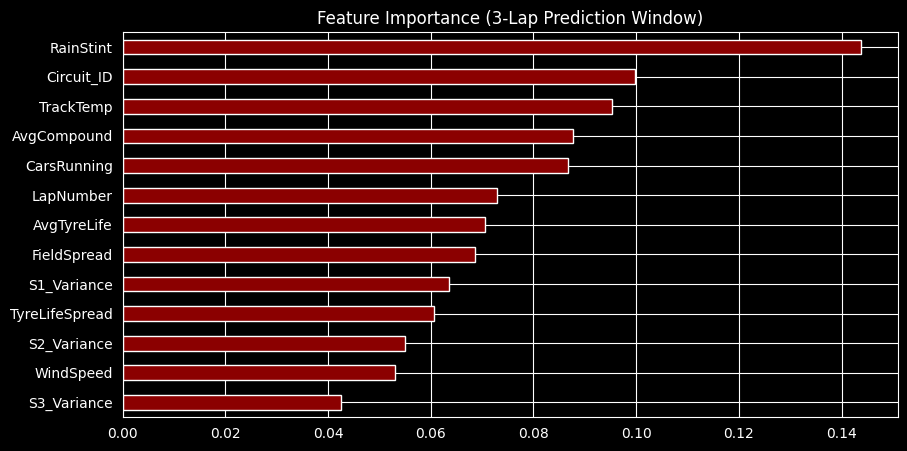

In [142]:
plt.figure(figsize=(10,5))
pd.Series(model.feature_importances_, index=features)\
  .sort_values()\
  .plot(kind='barh', color='darkred')

plt.title('Feature Importance (3-Lap Prediction Window)')
plt.show()


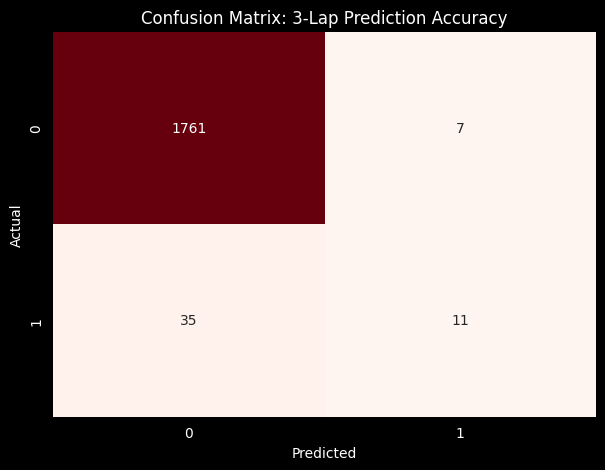

AUC-ROC: 0.9348

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1768
           1       0.61      0.24      0.34        46

    accuracy                           0.98      1814
   macro avg       0.80      0.62      0.67      1814
weighted avg       0.97      0.98      0.97      1814



In [143]:
probs = model.predict_proba(X_test)[:, 1]
preds = (probs > 0.5).astype(int)

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Confusion Matrix: 3-Lap Prediction Accuracy')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"AUC-ROC: {roc_auc_score(y_test, probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, preds))

